In [1]:
print("AI phishing detector started")


AI phishing detector started


In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn

PermissionError: [WinError 5] Access is denied

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("All libraries loaded ✅")

All libraries loaded ✅


In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/GregaVrbancic/Phishing-Dataset/master/dataset_full.csv")
print("Dataset loaded ✅")
print("Shape:", df.shape)
df.head()

Dataset loaded ✅
Shape: (88647, 112)


,qty_dot_url,qty_hyphen_url,qty_underline_url,qty_slash_url,qty_questionmark_url,qty_equal_url,qty_at_url,qty_and_url,qty_exclamation_url,qty_space_url,...,qty_ip_resolved,qty_nameservers,qty_mx_servers,ttl_hostname,tls_ssl_certificate,qty_redirects,url_google_index,domain_google_index,url_shortened,phishing
0,3,0,0,1,0,0,0,0,0,0,...,1,2,0,892,0,0,0,0,0,1
1,5,0,1,3,0,3,0,2,0,0,...,1,2,1,9540,1,0,0,0,0,1
2,2,0,0,1,0,0,0,0,0,0,...,1,2,3,589,1,0,0,0,0,0
3,4,0,2,5,0,0,0,0,0,0,...,1,2,0,292,1,0,0,0,0,1
4,2,0,0,0,0,0,0,0,0,0,...,1,2,1,3597,0,1,0,0,0,0


In [6]:
print("Class distribution:")
print(df['phishing'].value_counts())

Class distribution:
phishing
0    58000
1    30647
Name: count, dtype: int64


In [7]:
X = df.drop('phishing', axis=1)
y = df['phishing']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Features:", X_train.shape[1])
print("Data ready ✅")

Training samples: 70917
Testing samples: 17730
Features: 111
Data ready ✅


In [8]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained ✅")

Model trained ✅


In [9]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Phishing']))

Accuracy: 96.98%

Detailed Report:
              precision    recall  f1-score   support

  Legitimate       0.98      0.97      0.98     11612
    Phishing       0.95      0.96      0.96      6118

    accuracy                           0.97     17730
   macro avg       0.97      0.97      0.97     17730
weighted avg       0.97      0.97      0.97     17730



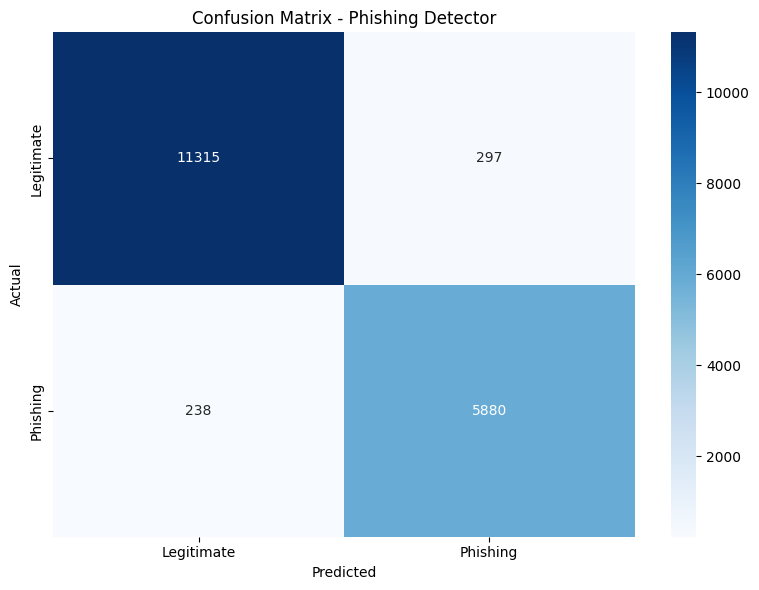

Confusion matrix saved ✅


In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix - Phishing Detector')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../model/confusion_matrix.png')
plt.show()
print("Confusion matrix saved ✅")

C:\Users\anupr\AppData\Local\Temp\ipykernel_18728\3749060536.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')


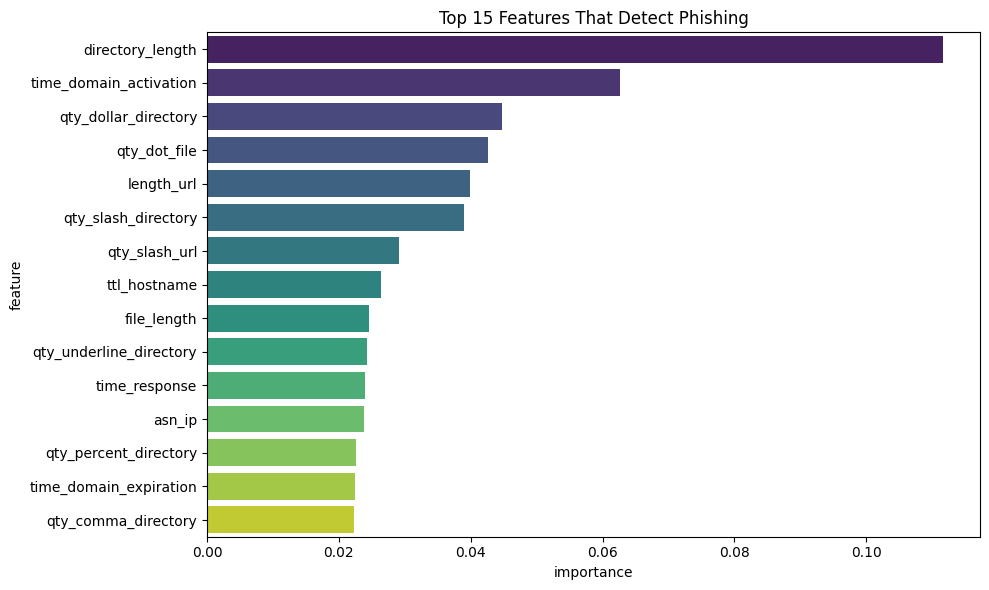

Feature importance saved ✅


In [11]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Features That Detect Phishing')
plt.tight_layout()
plt.savefig('../model/feature_importance.png')
plt.show()
print("Feature importance saved ✅")

In [13]:
import os
import joblib
joblib.dump(model, '../model/phishing_model.pkl')
print("Model saved as phishing_model.pkl ✅")
print("Size:", round(os.path.getsize('../model/phishing_model.pkl') / (1024*1024), 2), "MB")

Model saved as phishing_model.pkl ✅
Size: 54.81 MB
